
# Y2 AI Project: Stock Market Prediction

**COMP-H2003-Artificial Intelligence** - 20 November 2025

### Student Details
| Student | Student ID | Student Email |
| --- | --- | --- |
| Vanessa Aigbekaen | A00023488 | A00023488@myTUDublin.ie |


**Project Type:** Individual

**Year:** 2

**Module:** Artificial Intelligence

### Summary of Project Proposal

The aim of this project is to design a **machine learning classification model** that predicts whether the **SPF ETF** stock market will move **Up** (classified as 1) or **Down** (classified as 0) on the next trading day. The dataset being used is a historical daily price data from the **S&P 500 Index Tracker** which displays the market direction in a tabular and numerical format.

The model will analyse numerical features such as **Open, High, Low, Close Prices and Volume** togther with additional technical indicators to identify trends that are difficult for the human eyes to notice. A final graphical user interface will allow users to input data or connect to live sources and recieve real time prediction on market direction.

**Motto:**
`"Make money while you sleep - using AI models"`
          

### Dataset Details

| Feature | Short Description |
| --- | --- |
| Date | Date of trade |
| Close | Closing market price |
| High | Highest Price of the day |
| Low | Lowest Price of the day |
| Open | Openng market price |
| Volume | Total number of shares traded |

**Data Source:** SPY historical data (S&P 500 ETF), was generated using Python (yFinance) which is exactly the same as the dataset seen on the yahoo finance website.

**Data Period:** 14th of Auggust 2023 to current day

**Targert Feature:** 

- 1 : Market closes are higher than previous day (Up)
- 0 : Market closes are lower than previous day (Down)


### Questions Asked in Class + Answer

1. Can we add additional technical features such as RSI, MACD and ATR to improve model performance?

**Answer:** Yes, creating and adding additional features based on previous features is acceptable and can improve model performance.

**Actions Taken:** The following indicators were added:

- True Average
- Average True Range (ATR)

2. Is an accuracy between 50% to 60% acceptable for stock prediction?

**Answer:** Yes, the range is acceptable as stock market is relatively difficult to predict and even at that level money can still be made.

**Actions Taken:** Accuracy in this project ranges between 0.54 and 0.59

## 1. Data Cleaning and Wrangling

###  Import Libraries

#### Explanation
I imported important Python libraries required for data analysis and machine learning. These libraries provide fundamentals needed to load, process, clean, visualise and model dataset.

In [1]:
# Imported different modules needed for the task
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.impute import SimpleImputer
import joblib


### Load and Prepare Dataset

#### Explanation
I loaded the `SPY_data.csv` dataset using NumPy’s `genfromtxt`. Then skipped the first header rows, because: 

- Row 1 contains the label: Price, Close, High, Low, Open and Volume. 
- Row 2 contains the ticker repeated multiple times. 
- Row 3 contains the word date in the first column and the rest of the columns are blank.

These rows all contained non-numerical data, that is not needed for the model so they were skipped.

I then assigned each feature column:
- close_feature
- high_feature
- low_feature
- previous_close

These assigned features will be used to create other technical features.

In [2]:
# Created a file and stored it in a variable
# We read the file but skiped the first row as it contains column names.
filename = "SPY_data.csv"
data = np.genfromtxt(filename, delimiter=',', skip_header=1)

# Assigning different columns using indices
close_feature = 1
close_feature = data[:, close_feature]

high_feature = 2
high_feature = data[:, high_feature]

low_feature = 3
low_feature = data[:, low_feature]

# Getting previous prices by moving column down by 1 so I can compare.
# Got this code from geeks for geeks
previous_close = np.roll(close_feature, -1)

#The current day does not have a previos close
previous_close[0] = np.nan

## 2. Feature Selection and Pre-Processing

#### Added Technical Indicator Features
This will help improve predications of the models. I created **three New Features** based on market volatility and price movements:

- True Range
- Average True Range
- Target Column

These features were generated using previous features from SPY_data dataset (Open, Close, High, Low, Volume).

### True Range

True Range Calculates how much the price moves in One day. This is the formula for True Range:

**True Range (TR)=max(Current High−Current Low,∣Current High−Previous Close∣,∣Current Low−Previous Close∣)**

This Feature will help track features volatility and sudden movement in the market.

In [3]:
#Create a new feature called true range and assigned it with an empty arrray
trueRange = np.empty(len(close_feature))

# Creating a for loop that measures how much prce move in a day
for i in range(len(close_feature)):
    if i == 0:
        # Current days do not have true range
        trueRange[i] = high_feature[i]-low_feature[i]
    else:
        trueRange[i] =max(high_feature[i]-low_feature[i], abs(high_feature[i] - previous_close[i]), abs(low_feature[i] - previous_close[i]))

# Adding True range as a feature in the data
data = np.column_stack((data, trueRange))

### Average True Range

Average True Range as the name says it all is the average of the truevrange over 14 days. This is the formula for Average True Range:

**ATR = Moving Average of True Range (TR) / 14**

This gives a stronger sense of market direction strength and volatility

In [4]:
#Create a new feature called average true range and assigned it with an empty arrray
averageTrueRange = np.empty(len(trueRange))
twoWeekPeriod = 14

# Creating a for loop that measures the average movement of prices daily
# Got code from stacksoverflow (properl referenced at the bottom)
for i in range(len(trueRange)):
    if i < twoWeekPeriod:
        # Loops till it has enough rows(2 weeks)
        averageTrueRange[i] = np.mean(trueRange[:i+1])
    else:
        averageTrueRange[i] = np.mean(trueRange[i-twoWeekPeriod+1:i+1])

# Adding Average true range as a feature in the data
data = np.column_stack((data, averageTrueRange))

### Target column

Target column predicts tomorrow's market direction using binary classsification, with 1 being up and 0 being down.

In [5]:
# Getting tomorrows prices by moving column up by 1 so I can compare.
# Got this code from geeks for geeks
tomorrows_close = np.roll(close_feature, -1)

# Creating a target row
# With one meaning up(buy) and zero meaning down(sell) 
Target = (tomorrows_close >close_feature).astype(int)
data = np.column_stack((data, Target))

data = data[:-1, :]
Target = Target[:-1]

### Data Anaylsis

The three Features of data I'm focusing on is Volume True Range and Average True Range.

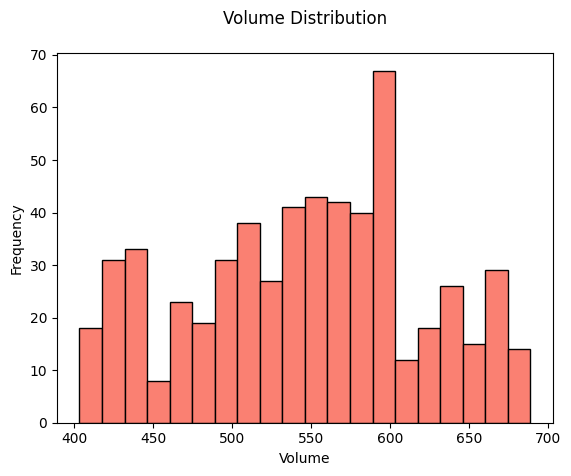

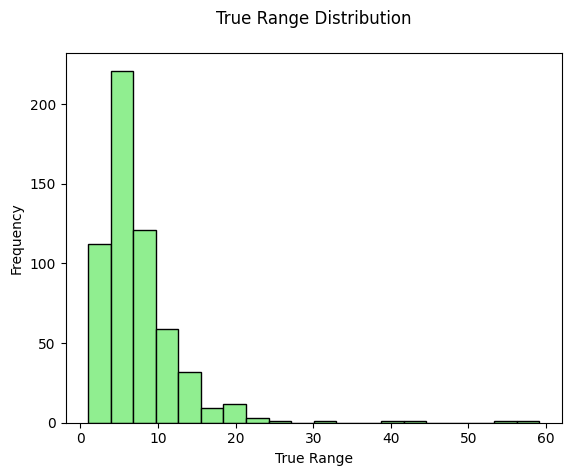

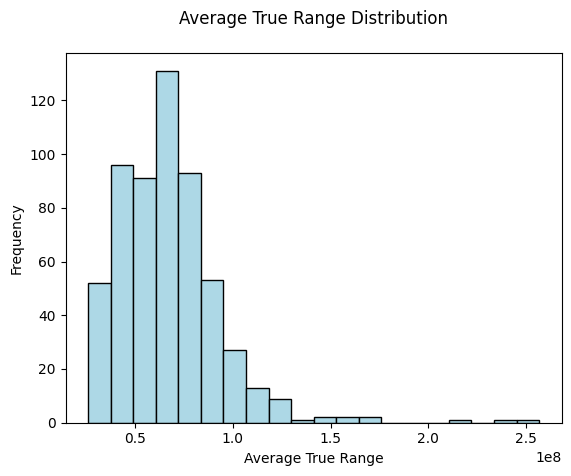

In [ ]:
#Displaying all the data in a histogram graph.
volumeGraph = data[:,4]
ATRgraph = data[:,5]
TR = data[:,6]

#Volume
#It has a Normal/Triangular distribution 
plt.hist(volumeGraph, bins = 20, color= "salmon", edgecolor='black')
plt.title("Volume Distribution\n")
plt.xlabel("Volume")
plt.ylabel("Frequency")
plt.show()

#True Range
#It has a skewed distribution to the left
plt.hist(TR, bins = 20, color= "lightgreen", edgecolor='black')
plt.title("True Range Distribution\n")
plt.xlabel("True Range")
plt.ylabel("Frequency")
plt.show()

#Average True Range
#It has a skewed distribution to the left
plt.hist(ATRgraph, bins = 20, color= "lightblue", edgecolor='black')
plt.title("Average True Range Distribution\n")
plt.xlabel("Average True Range")
plt.ylabel("Frequency")
plt.show()


#### Handling Missing Values

Since the first few rows of the Average True Range and True Range contain "NAN", missing values were replaced with the mean of the column:

- SimpleImputer(strategy = "mean")

#### Removing Unclean Rows

I removed rows containing zeros in all columns to avoid corrupting or invalid data that could negatively affect model.

#### Assigning X and y

- X contains all the numeric features (Close, High, Low, Open, Volume, True Range and Average True Range)
- y contains the Target (0 or 1)

In [7]:
# Removed the 1, 2 and 3 row
rows_to_remove = [0, 1, 2]
data = np.delete(data, rows_to_remove, axis = 0)

# Ignore the first column
data = data[:, 1:]

# Read all the data in each row stored it in a variable called x
# Read the last column of the row which was the state and stored it in a variable called y
X = data[:, :-1]
y = data[:, -1].astype(int)

#filled rows that have zero or not a number with an average of that row (Refeernced where I got this code below)
imputer = SimpleImputer(strategy = "mean")
X = imputer.fit_transform(X)

# Removed all the unclean data, that is all the features that contains a zero in each row.
# The axis checks if the rows true(contains all zeros) or false(contains zeros and other numbers)
unclean_data = ~(X == 0). all(axis =1)
X = X[unclean_data]
y = y[unclean_data]

# Displayed the number of row and features
print("Data shape:", data.shape)
print("Feature shape:", X.shape, "Target shape:", y.shape)

Data shape: (574, 8)
Feature shape: (574, 7) Target shape: (574,)


## 3. Split into Train, Validation, and Test Sets

### Explanation
To ensure fair evalution and distribution, the dataset was divided as follows:
- **Training set**: 60%
- **Validation set**: 20%
- **Test set**: 20%

The Train set allows models to learn patterns, the Validation set allows model to see its performance and the Test set shows models neutral evaluation.

In [8]:
# 60% of the data is Trained
# 20% of the data is Validated
# 20% of the data is Test Set
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print("Train set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)


Train set: (344, 7)
Validation set: (115, 7)
Test set: (115, 7)


In [9]:
# Created a function that plots the confusion matrix
def plot_confusion_matrix(cm, title):
    fig, ax = plt.subplots(figsize=(3.5,3.5))
    ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center', color='black')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    plt.show()


## 4. Model and Model Comparison

To compare the performance of the two models: **Logistic Regression** and **Naive Baye**. 

I evaluated thier accuracy on both the Validation set and Test set:
- The **Logistic Regression** achieved a **validation accuracy** of **0.5826** and **test accuracy** of **0.5826**, showing consistent performance across seen and unseen data. 
- The **Naive Bayes** model achieved a **validation accuracy** of 0.565 and **test accuracy** of 0.565, which were slightly lower than Logistic Regression.

These Results show that **Logistic Regression** is best overall for predicting next-day market direction based on selected features. The identical validation and test accuracy values show models did not suffer from overfitting. Even though the accuracy values are not that high (which is expected in stock market prediction), the comparison shows **Logistic Regression** is more reliable for this dataset.

## Logistic Regression

Reasons for choosing Logistic Regression:

- Performs well on Binary Classification.
- It avoids overfitting compared to other complex models.
- Provides stable and interpretable results.

Validation Accuracy: 0.5826086956521739 
Test Accuracy: 0.5826086956521739


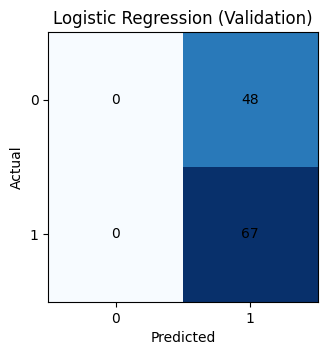

In [10]:
# Assigned the logistic Model to a variable
# We then passed a parameter of 1000 (the number iterations the model can take before deciding the best one) 
log_reg = LogisticRegression(max_iter=1000)

# Train the data
log_reg.fit(X_train, y_train)

# Make it's predications based on the Validation set and Test set
y_val_lr = log_reg.predict(X_val)
y_test_lr = log_reg.predict(X_test)

# Comparing the actual labels vs the predicted label
val_acc_lr = accuracy_score(y_val, y_val_lr)
test_acc_lr = accuracy_score(y_test, y_test_lr)

# Assigned the confusion matrix and gave it 2 parameters
# Ploted the confusion matrix graph
cm_lr = confusion_matrix(y_val, y_val_lr)
print("Validation Accuracy:", val_acc_lr, "\nTest Accuracy:", test_acc_lr)
plot_confusion_matrix(cm_lr, "Logistic Regression (Validation)")


## Naive Bayes

Reasons for choosing Naive Bayes:

- Simple, Fast and Works well with independent features. 
- Works well with complex data like the stock market.


Validation Accuracy: 0.5652173913043478 
Test Accuracy: 0.5652173913043478


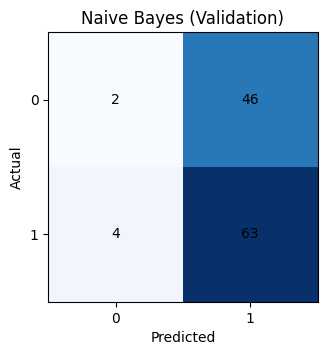

In [11]:
# Assigned the Naive Bayes Model to a variable
nb = GaussianNB()

# Train the data
nb.fit(X_train, y_train)

# Make it's predications based on the Validation set and Test set
y_val_nb = nb.predict(X_val)
y_test_nb = nb.predict(X_test)

# Comparing the actual labels vs the predicted label
val_acc_nb = accuracy_score(y_val, y_val_nb)
test_acc_nb = accuracy_score(y_test, y_test_nb)

# Assigned the confusion matrix and gave it 2 parameters
# Ploted the confusion matrix graph
cm_nb = confusion_matrix(y_val, y_val_nb)
print("Validation Accuracy:", val_acc_nb, "\nTest Accuracy:", test_acc_nb)
plot_confusion_matrix(cm_nb, "Naive Bayes (Validation)")


### Overfitting Observed
When I tested **Random Forest** and **Gradient Boosting**, I noticed a very high validation accuracy and very low test accuracy. This indicates **`Overfitting`** meaning the model was memorising the `"noise"` instead of learning general patterns. I documented this because it shows technical understanding. 

### Accuracy Comparison

Comparing the different models and putting it on a graph
- The model's comparison is based on it's **Predictions** for the validation set and test set.

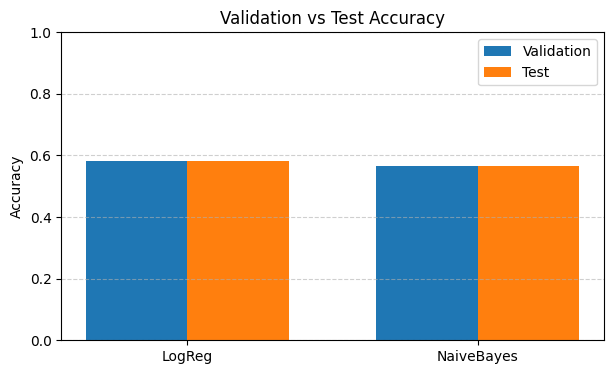

In [12]:
# Assigning values to create the graph
models = ["LogReg","NaiveBayes"]
val_accs = [val_acc_lr, val_acc_nb]
test_accs = [test_acc_lr, test_acc_nb]

x = np.arange(len(models))
width = 0.35

# Ploting the gragh
plt.figure(figsize=(7,4))
plt.bar(x - width/2, val_accs, width, label="Validation")
plt.bar(x + width/2, test_accs, width, label="Test")
plt.xticks(x, models)
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Validation vs Test Accuracy")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


## 5. Evaluation

### ROC Curve Evalution

To further evaluate the models, I compared their Receiver Operating Characteristic (ROC) curves. The ROC curve for logistic Regression was noticeably more steeper and rising more sharply toward the upper-left corner of the graph. This shows a higher **true positive rate** for the same **false positive rate**, this means the models better at identifying **upward market movements** from **downward market movements**. 

In the same note, Naive Bayes ROC was **less steep and sharp**, showing it is weaker in distinguishing target class (0 and 1). 

The steeper the ROC curve, the better the model's distinguishing power, therefore, this reiterates why Logistic Regression is the best model for this project.



I also evaluated the **Area Under the Curve** for both models. **Logistic Regression** produced a AUC score of 0.54 while **Naive Baye** produced a AUC score of 0.44. An AUC score of 0.5 means that the model  is random guessing so Logistic Regression performed slightly better than guessing, whereas Naive Baye performed slightly worse than guessing. Although an AUC of 5.4 is not that high , it is higher than Naive Baye.

Even with all the noise coming from financial markets due to **extreme price movements** an AUC 0.5 is common for simple models and basic technical features. The comparison clearly shows Logistic Regression as the strongest for this specific feature set and dataset.

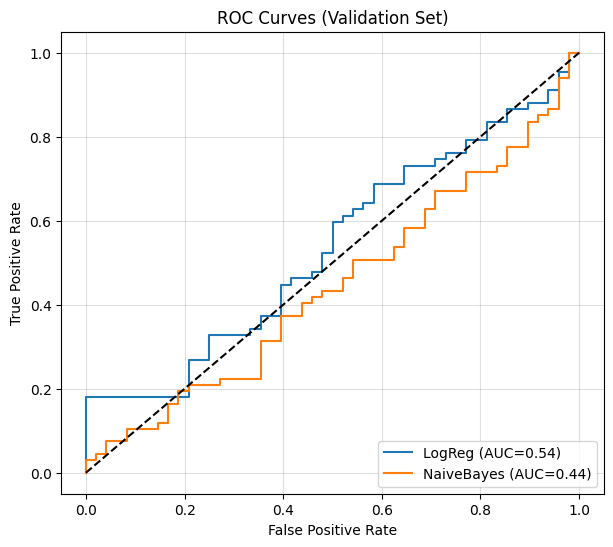

In [13]:

plt.figure(figsize=(7,6))

# Created a for loop that reads each model and compares it too the last label (state)
for name, model in [("LogReg", log_reg), ("NaiveBayes", nb)]:
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_val)[:, 1]
        fpr, tpr, _ = roc_curve(y_val, y_prob)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.2f})")

# Plot the graph
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (Validation Set)")
plt.legend(loc="lower right")
plt.grid(alpha=0.4)
plt.show()


## 6. Save Best Model for Demo Program

### Explanation
Logistic Regression was saved using `joblib`. This file is then loaded into the GUI program to perform real-time predications based on the latest market data.

In [14]:
# Assigning validation scores
val_scores = {
    "Logistic Regression": val_acc_lr,
    "Naive Bayes": val_acc_nb,
}

# Printed out the best model
best_model_name = max(val_scores, key=val_scores.get)
print("Best model based on validation accuracy:", best_model_name)

best_model = {
    "Logistic Regression": log_reg,
    "Naive Bayes": nb,
}[best_model_name]

# Saved the best model in the  joblib file
joblib.dump(best_model, "best_spy_model.joblib")
print("Saved best model to best_spy_model.joblib")


Best model based on validation accuracy: Logistic Regression
Saved best model to best_spy_model.joblib


## References

- GeeksforGeeks (2017). Naive Bayes Classifiers. [online] GeeksforGeeks. Available at: https://share.google/OubhJy1S2915i7SN6 [Accessed 2025].
- cardycakes (2016). Calculating Average True Range (ATR) on OHLC data with Python. [online] Stack Overflow. Available at: https://stackoverflow.com/questions/40256338/calculating-average-true-range-atr-on-ohlc-data-with-python.
- Dakalbab, F., Talib, M.A., Nasir, Q. and Saroufil, T. (2024). Artificial intelligence techniques in financial trading: A systematic literature review. Journal of King Saud University. Computer and information sciences/Maǧalaẗ ǧamʼaẗ al-malīk Saud : ùlm al-ḥasib wa al-maʼlumat, [online] 36(3), pp.102015–102015. doi:https://doi.org/10.1016/j.jksuci.2024.102015.
- GeeksforGeeks (2017). Understanding the Confusion Matrix in Machine Learning. [online] GeeksforGeeks. Available at: https://www.geeksforgeeks.org/machine-learning/confusion-matrix-machine-learning/.
- ChatGBT for the GUI design

